In [1]:
# Carga de librerias y dataset de prestamos bancarios (Loan Approval)
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

Descarga del dataset desde Kaggle (opcion simple con kagglehub)

In [2]:
!pip install kagglehub -q
import kagglehub

ruta = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
marco_datos = pd.read_csv(f"{ruta}/loan_data.csv")


100%|██████████| 751k/751k [00:00<00:00, 797kB/s]

Extracting files...


Clases del target: 0 = rechazado, 1 = aprobado

In [3]:
marco_datos['loan_status'].unique()


array([1, 0])

Datos y columnas con descripcion de caracteristicas

In [4]:
marco_datos


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


Las columnas de texto (categoricas) hay que pasarlas a numeros para que KNN las pueda usar

In [5]:
marco_datos['person_gender'] = marco_datos['person_gender'].astype('category').cat.codes
marco_datos['person_education'] = marco_datos['person_education'].astype('category').cat.codes
marco_datos['person_home_ownership'] = marco_datos['person_home_ownership'].astype('category').cat.codes
marco_datos['loan_intent'] = marco_datos['loan_intent'].astype('category').cat.codes
marco_datos['previous_loan_defaults_on_file'] = marco_datos['previous_loan_defaults_on_file'].astype('category').cat.codes

marco_datos.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


Filtro de ejemplo: ver solo los prestamos aprobados

In [6]:
marco_datos[marco_datos.loan_status == 1]


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1
5,21.0,0,3,12951.0,0,2,2500.0,5,7.14,0.19,2.0,532,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,1,0,47971.0,6,3,15000.0,3,15.66,0.31,3.0,645,0,1
44996,37.0,0,0,65800.0,17,3,9000.0,2,14.07,0.14,11.0,621,0,1
44997,33.0,1,0,56942.0,7,3,2771.0,0,10.02,0.05,10.0,668,0,1
44998,29.0,1,1,33164.0,4,3,12000.0,1,13.23,0.36,6.0,604,0,1


Separacion para graficar: aprobados vs rechazados

In [7]:
aprobados = marco_datos[marco_datos.loan_status == 1]
rechazados = marco_datos[marco_datos.loan_status == 0]


In [8]:
import matplotlib.pyplot as plt
%matplotlib inline


Grafico de ingreso vs puntaje crediticio. Rechazados en rojo, aprobados en azul

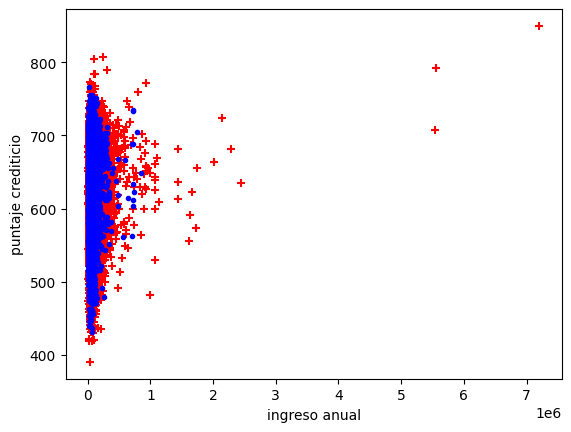

In [9]:
plt.xlabel('ingreso anual')
plt.ylabel('puntaje crediticio')
plt.scatter(rechazados['person_income'], rechazados['credit_score'], color="red", marker="+")
plt.scatter(aprobados['person_income'], aprobados['credit_score'], color="blue", marker=".")


In [10]:
from sklearn.model_selection import train_test_split


Separacion en eje x datos, eje y caracteristicas (el target)

In [11]:
x = marco_datos.drop(['loan_status'], axis='columns')
y = marco_datos.loan_status


Datos para entrenamiento y verificacion/testing

In [12]:
x_entrenamiento, x_verificacion, y_entrenamiento, y_verificacion = train_test_split(x, y, test_size=0.2,
                                                                                    random_state=1)


KNN de sklearn. K = 15

In [13]:
kvc = KNeighborsClassifier(n_neighbors=15)


Entrenamiento del modelo.

In [14]:
kvc.fit(x_entrenamiento, y_entrenamiento)


KNeighborsClassifier(n_neighbors=15)

Rendimiento del modelo

In [15]:
kvc.score(x_verificacion, y_verificacion)


0.8336666666666667

Prueba con un solicitante inventado (mismo orden de columnas que x)

In [16]:
resultado = kvc.predict(x_verificacion[0:1])
if resultado[0] == 0:
  print("predijo prestamo rechazado")
else:
  print("predijo prestamo aprobado")


predijo prestamo rechazado


In [17]:
resultado


array([0])

Matriz de confusion

In [18]:
from sklearn.metrics import confusion_matrix


In [19]:
prediccion_y = kvc.predict(x_verificacion)
cm = confusion_matrix(y_verificacion, prediccion_y)
cm


array([[6515,  407],
       [1090,  988]])

In [20]:
for k in [3, 5, 7, 9, 11, 15, 21]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(x_entrenamiento, y_entrenamiento)
    pred = modelo.predict(x_verificacion)
    cm = confusion_matrix(y_verificacion, pred)
    print("k =", k, "| accuracy =", modelo.score(x_verificacion, y_verificacion), "| matriz:", cm.tolist())

k = 3 | accuracy = 0.8206666666666667 | matriz: [[6315, 607], [1007, 1071]]
k = 5 | accuracy = 0.8267777777777777 | matriz: [[6402, 520], [1039, 1039]]
k = 7 | accuracy = 0.8316666666666667 | matriz: [[6472, 450], [1065, 1013]]
k = 9 | accuracy = 0.8314444444444444 | matriz: [[6473, 449], [1068, 1010]]
k = 11 | accuracy = 0.831 | matriz: [[6481, 441], [1080, 998]]
k = 15 | accuracy = 0.8336666666666667 | matriz: [[6515, 407], [1090, 988]]
k = 21 | accuracy = 0.8373333333333334 | matriz: [[6558, 364], [1100, 978]]
